# Portofolio Multi-Coin + Rebalance (konsep "seperti saham")

**Konsep user**: pegang beberapa coin sekaligus; rugi di satu coin ditutup untung coin lain; modal
di-rebalance. Strategi berbeda per kelompok karakter (notebook 14).

### Keputusan user (sebelum uji)
- Universe = kelompok **coin utama** (BTC, ETH, BNB, XRP, ADA, LINK, TRX) + **DOGE porsi kecil (maks 10%)**.
- **LTC & BCH dikeluarkan** (kelompok paling lemah di notebook 14).
- Porsi **disesuaikan volatilitas** (inverse volatility 60 hari); porsi sama rata diuji sebagai pembanding.

### Variasi (ditetapkan sebelum melihat periode uji)
| Kode | Aturan |
|---|---|
| V1 | Semua coin dipegang, porsi inverse-vol, **rebalance saja** (tanpa filter) |
| V2 | V1 + **filter pasar** H8b (BTC > SMA100 atau FGI 14 hari > 50; else semua cash) |
| V3 | V2 + **filter tren per coin** kelompok utama (coin < SMA100 sendiri → porsinya jadi cash) + **DOGE mean-reversion** (beli di bawah Bollinger bawah 20/2σ, jual di atas SMA20; tidak ikut filter pasar, maks 10%) |
| V4 | V3 dengan porsi **sama rata** |
| — | tiap variasi: rebalance **mingguan (W)** dan **bulanan (M)** |
| Pembanding | **Strategi 13** (BTC saja, H8b) di mesin yang sama; buy & hold BTC |

Coin yang terfilter keluar → porsinya jadi **cash** (tidak dibagi ke coin lain).
Filter berubah → langsung rebalance di open besok (tidak menunggu jadwal), biaya 0.15% dari nilai transaksi.

### Periode
- **Pemilihan**: 2018-07 → 2022-12 (Sharpe tertinggi).
- **Uji akhir**: 2023-01 → 2026-06.
- ⚠️ **Catatan jujur**: filter pasar H8b dipilih di notebook 13 dengan data sampai 2026, jadi komponen itu
  sudah "pernah melihat" periode uji. Bagian lain (porsi, filter per coin, DOGE, frekuensi) belum.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index
from research.single_position import Panel, BTC
from research.portfolio import run_portfolio, inverse_vol_weights, equal_weights

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
MAIN = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "ADAUSDT", "LINKUSDT", "TRXUSDT"]
DOGE = "DOGEUSDT"
UNIV = MAIN + [DOGE]
CAPS = {DOGE: 0.10}
DEV, TEST = ("2018-07-01", "2022-12-31"), ("2023-01-01", "2026-06-30")
P = Panel({s: load_symbol(s, "1d", "since2018") for s in UNIV}, "2018-01-01", "2026-06-30")
fgi = load_fear_greed_index()["fng_value"].reindex(P.dates).ffill()
btc = P.close[BTC]
print("Universe:", [s[:-4] for s in UNIV], "| DOGE maks 10%")

Universe: ['BTC', 'ETH', 'BNB', 'XRP', 'ADA', 'LINK', 'TRX', 'DOGE'] | DOGE maks 10%


## 1. Sinyal & porsi

In [2]:
market = (btc > btc.rolling(100, min_periods=100).mean()) | (fgi.rolling(14).mean() > 50)   # H8b
coin_trend = P.close[MAIN] > P.close[MAIN].rolling(100, min_periods=100).mean()

def mean_rev_signal(close):
    ma, sd = close.rolling(20).mean(), close.rolling(20).std()
    s, out = False, []
    for c, m, lo in zip(close, ma, ma - 2 * sd):
        s = True if (not s and c < lo) else (False if (s and c > m) else s)
        out.append(s)
    return pd.Series(out, index=close.index)

doge_mr = mean_rev_signal(P.close[DOGE])
base = {"inv-vol": inverse_vol_weights(P, UNIV, 60, CAPS), "sama rata": equal_weights(P, UNIV, CAPS)}

def build(kind, weighting):
    w = base[weighting].copy()
    if kind == "V1":
        return w
    if kind == "V2":
        return w.mul(market.astype(float), axis=0)
    # V3 / V4
    w[MAIN] = w[MAIN].mul(market.astype(float), axis=0) * coin_trend.astype(float)
    w[DOGE] = w[DOGE] * doge_mr.astype(float)
    return w

VARIANTS = {}
for kind, weighting in (("V1", "inv-vol"), ("V2", "inv-vol"), ("V3", "inv-vol"), ("V4", "sama rata")):
    for freq in ("W", "M"):
        VARIANTS[f"{kind} {weighting} {freq}"] = (build(kind, weighting), freq)
# pembanding di mesin yang sama
only_btc = pd.DataFrame(0.0, index=P.dates, columns=UNIV); only_btc[BTC] = market.astype(float)
hold_btc = pd.DataFrame(0.0, index=P.dates, columns=UNIV); hold_btc[BTC] = 1.0
BENCH = {"Strategi 13 (BTC H8b 100%)": (only_btc, "M"), "Strategi 13 (BTC H8b 60%)": (only_btc * 0.6, "M"),
         "Buy & hold BTC": (hold_btc, "M")}
print("Porsi inverse-vol rata-rata 2019-2022:")
print(base["inv-vol"].loc["2019":"2022"].mean().rename(lambda s: s[:-4]).map(lambda v: f"{v:.0%}").to_string())

Porsi inverse-vol rata-rata 2019-2022:
BTC     18%
ETH     13%
BNB     14%
XRP     13%
ADA     12%
LINK    10%
TRX     14%
DOGE     7%


## 2. Hasil semua variasi

In [3]:
def stats(eq, info):
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    tot = eq.iloc[-1] / eq.iloc[0] - 1
    dd = (eq / eq.cummax() - 1).min()
    dr = eq.pct_change().dropna()
    mon = eq.resample("ME").last().pct_change().dropna()
    yr = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
    return dict(profit=tot, cagr=(1 + tot) ** (1 / years) - 1, max_dd=dd,
                sharpe=dr.mean() / dr.std() * np.sqrt(365) if dr.std() > 0 else np.nan,
                tahun_terburuk=yr.min(), bulan_untung=(mon > 0).mean(), bulan_terburuk=mon.min(),
                n_rebalance=info["n_rebalance"], turnover_per_thn=info["turnover"] / eq.mean() / years)

rows, curves, infos = [], {}, {}
for name, (w, freq) in {**VARIANTS, **BENCH}.items():
    r = dict(strategi=name)
    for tag, per in (("dev", DEV), ("uji", TEST)):
        eq, info = run_portfolio(P, w, *per, freq=freq)
        curves[(name, tag)], infos[(name, tag)] = eq, info
        r.update({f"{tag}_{k}": v for k, v in stats(eq, info).items()})
    rows.append(r)
res = pd.DataFrame(rows).set_index("strategi")
PCT = [c for c in res.columns if any(k in c for k in ("profit", "cagr", "max_dd", "tahun", "bulan"))]
show = res[["dev_profit", "dev_max_dd", "dev_sharpe", "uji_profit", "uji_cagr", "uji_max_dd", "uji_sharpe",
            "uji_tahun_terburuk", "uji_bulan_untung", "uji_bulan_terburuk", "uji_turnover_per_thn"]].copy().astype(object)
for c in show.columns:
    show[c] = res[c].map(lambda v: f"{v:+.0%}" if c in PCT else f"{v:.2f}")
show

,dev_profit,dev_max_dd,dev_sharpe,uji_profit,uji_cagr,uji_max_dd,uji_sharpe,uji_tahun_terburuk,uji_bulan_untung,uji_bulan_terburuk,uji_turnover_per_thn
strategi,,,,,,,,,,,
V1 inv-vol W,+1004%,-73%,1.06,+213%,+39%,-55%,0.90,-32%,+59%,-24%,3.82
V1 inv-vol M,+1595%,-73%,1.15,+217%,+39%,-56%,0.90,-33%,+59%,-26%,2.15
V2 inv-vol W,+3613%,-45%,1.68,+284%,+47%,-36%,1.13,-4%,+44%,-18%,11.76
V2 inv-vol M,+5458%,-45%,1.70,+306%,+49%,-34%,1.16,-4%,+44%,-18%,10.56
V3 inv-vol W,+2081%,-37%,1.65,+112%,+24%,-31%,0.85,-5%,+46%,-13%,17.85
V3 inv-vol M,+2575%,-38%,1.66,+121%,+26%,-31%,0.88,-5%,+46%,-13%,17.22
V4 sama rata W,+2007%,-37%,1.57,+98%,+22%,-33%,0.77,-7%,+44%,-15%,16.65
V4 sama rata M,+2258%,-38%,1.58,+105%,+23%,-34%,0.79,-6%,+44%,-15%,16.20
Strategi 13 (BTC H8b 100%),+732%,-39%,1.20,+253%,+43%,-32%,1.14,-8%,+46%,-15%,9.01


## 3. Pemilihan (hanya dari periode dev) & uji akhir

In [4]:
cand = res.loc[list(VARIANTS)]
chosen = cand["dev_sharpe"].idxmax()
print(f"Variasi terpilih (Sharpe dev tertinggi): {chosen}")
b13 = res.loc["Strategi 13 (BTC H8b 100%)"]
c = res.loc[chosen]
for k, label in (("profit", "Profit"), ("cagr", "Profit/tahun"), ("max_dd", "Max drawdown"), ("sharpe", "Sharpe"),
                 ("tahun_terburuk", "Tahun terburuk"), ("bulan_untung", "% bulan untung")):
    f = (lambda v: f"{v:.2f}") if k == "sharpe" else (lambda v: f"{v:+.0%}")
    print(f"  {label:15s} dev: {f(c['dev_' + k]):>6} vs 13: {f(b13['dev_' + k]):>6}  |  uji: {f(c['uji_' + k]):>6} vs 13: {f(b13['uji_' + k]):>6}")

Variasi terpilih (Sharpe dev tertinggi): V2 inv-vol M
  Profit          dev: +5458% vs 13:  +732%  |  uji:  +306% vs 13:  +253%
  Profit/tahun    dev:  +144% vs 13:   +60%  |  uji:   +49% vs 13:   +43%
  Max drawdown    dev:   -45% vs 13:   -39%  |  uji:   -34% vs 13:   -32%
  Sharpe          dev:   1.70 vs 13:   1.20  |  uji:   1.16 vs 13:   1.14
  Tahun terburuk  dev:   -21% vs 13:   -21%  |  uji:    -4% vs 13:    -8%
  % bulan untung  dev:   +40% vs 13:   +32%  |  uji:   +44% vs 13:   +46%


In [5]:
# Return per tahun: variasi terpilih vs pembanding
yr = {}
for name in [chosen, "V1 inv-vol M", "Strategi 13 (BTC H8b 100%)", "Buy & hold BTC"]:
    w, freq = {**VARIANTS, **BENCH}[name]
    eq, _ = run_portfolio(P, w, DEV[0], TEST[1], freq=freq)
    yr[name] = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
t = pd.DataFrame(yr).T
t.columns = [f"{y}{' (Jul-)' if y == 2018 else (' (-Jun)' if y == 2026 else '')}" for y in t.columns]
t.map(lambda v: f"{v:+.0%}")

,2018 (Jul-),2019,2020,2021,2022,2023,2024,2025,2026 (-Jun)
V2 inv-vol M,-21%,+61%,+231%,+1445%,-17%,+72%,+122%,+5%,-4%
V1 inv-vol M,-51%,+48%,+367%,+967%,-57%,+106%,+158%,-18%,-33%
Strategi 13 (BTC H8b 100%),-9%,+134%,+188%,+70%,-21%,+89%,+89%,+1%,-8%
Buy & hold BTC,-42%,+89%,+302%,+58%,-65%,+154%,+112%,-7%,-34%


In [6]:
# Kontribusi untung/rugi per coin (periode uji) + apakah "rugi satu coin ditutup coin lain"?
info = infos[(chosen, "uji")]
contrib = info["pnl_per_coin"].rename(lambda s: s[:-4]).sort_values(ascending=False)
print(f"{chosen} — kontribusi PnL per coin di periode uji (modal awal = 1.0):")
print(contrib.map(lambda v: f"{v:+.3f}").to_string())
# bulan di mana ada coin rugi tapi portofolio tetap untung
w, freq = VARIANTS[chosen]
eq, _ = run_portfolio(P, w, *TEST, freq=freq)
mon = eq.resample("ME").last().pct_change().dropna()
coin_mon = P.close[UNIV].loc[TEST[0]:TEST[1]].resample("ME").last().pct_change().dropna()
held = w.loc[TEST[0]:TEST[1]].resample("ME").mean().reindex(coin_mon.index) > 0.01
some_loss = ((coin_mon < 0) & held).any(axis=1)
print(f"\nBulan dengan minimal 1 coin (yang dipegang) turun: {some_loss.sum()} dari {len(mon)}; "
      f"portofolio tetap untung di {(some_loss & (mon.reindex(some_loss.index) > 0)).sum()} bulan itu")

V2 inv-vol M — kontribusi PnL per coin di periode uji (modal awal = 1.0):
XRP     +0.780
BNB     +0.623
TRX     +0.616
DOGE    +0.249
ETH     +0.225
BTC     +0.214
ADA     +0.199
LINK    +0.160

Bulan dengan minimal 1 coin (yang dipegang) turun: 27 dari 41; portofolio tetap untung di 12 bulan itu


## 4. Uji ketahanan variasi terpilih

In [7]:
rows = []
w, freq = VARIANTS[chosen]
for label, kw in (("uji normal", {}), ("uji biaya 2x", dict(cost=0.003))):
    eq, info = run_portfolio(P, w, *TEST, freq=freq, **kw)
    rows.append(dict(uji=label, **stats(eq, info)))
for s in UNIV:
    w2 = w.drop(columns=s)
    eq, info = run_portfolio(P, w2, *TEST, freq=freq)
    rows.append(dict(uji=f"tanpa {s[:-4]}", **stats(eq, info)))
for k in (0.6,):
    eq, info = run_portfolio(P, w * k, *TEST, freq=freq)
    rows.append(dict(uji=f"porsi total {k:.0%}", **stats(eq, info)))
rob = pd.DataFrame(rows).set_index("uji")
out = rob[["profit", "cagr", "max_dd", "sharpe", "tahun_terburuk"]].copy().astype(object)
for c in out.columns:
    out[c] = rob[c].map(lambda v: f"{v:.2f}" if c == "sharpe" else f"{v:+.0%}")
out

,profit,cagr,max_dd,sharpe,tahun_terburuk
uji,,,,,
uji normal,+306%,+49%,-34%,1.16,-4%
uji biaya 2x,+285%,+47%,-34%,1.12,-5%
tanpa BTC,+256%,+44%,-30%,1.14,-3%
tanpa ETH,+276%,+46%,-29%,1.19,-3%
tanpa BNB,+246%,+43%,-32%,1.13,-5%
tanpa XRP,+208%,+38%,-31%,1.05,-2%
tanpa ADA,+277%,+46%,-27%,1.21,-3%
tanpa LINK,+288%,+47%,-29%,1.21,-3%
tanpa TRX,+228%,+40%,-32%,1.09,-5%


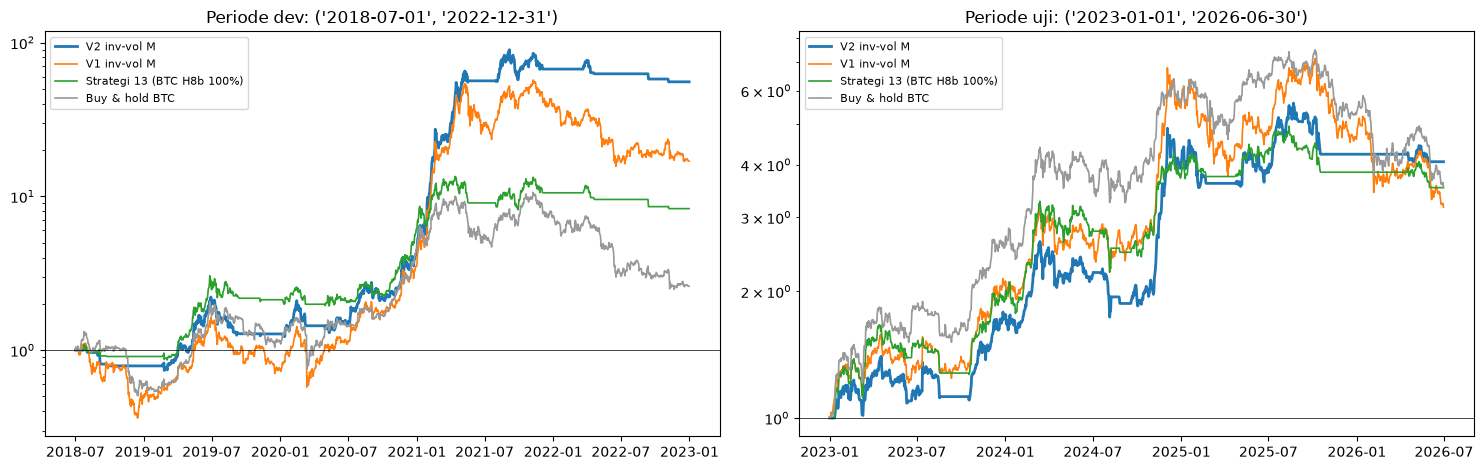

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, tag in zip(axes, ("dev", "uji")):
    for name in [chosen, "V1 inv-vol M", "Strategi 13 (BTC H8b 100%)", "Buy & hold BTC"]:
        e = curves[(name, tag)]
        ax.plot(e.index, e / e.iloc[0], lw=2 if name == chosen else 1.2, label=name,
                color="#999999" if name.startswith("Buy") else None)
    ax.set_yscale("log"); ax.axhline(1, color="black", lw=0.5)
    ax.set_title(f"Periode {tag}: {DEV if tag == 'dev' else TEST}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Kesimpulan

### Terpilih (dari periode dev): **V2 — portofolio 8 coin, porsi inverse-vol, filter pasar, rebalance bulanan**

| Periode uji 2023-01 → 2026-06 | **V2 portofolio** | Strategi 13 (BTC saja) | Buy & hold BTC |
|---|---|---|---|
| Profit | **+307%** | +253% | +253% |
| Profit/tahun | **+49%** | +43% | +43% |
| Max drawdown | −34% | **−32%** | −53% |
| Sharpe | **1.16** | 1.14 | 1.00 |
| Tahun terburuk | **−4%** | −8% | −34% |
| Bulan terburuk | −18% | −15% | −20% |

Di periode dev (2018-07 → 2022) V2 jauh lebih unggul (Sharpe 1.70 vs 1.20), terutama karena bull
altcoin 2021 (+1.449%).

### Apa yang terbukti
1. **Konsep portofolio + rebalance bekerja** — tapi hanya **bersama filter pasar**. Tanpa filter (V1),
   portofolio ikut hancur saat crash (2022: −57%, 2026: −33%). Dengan filter (V2): 2022 −17%, 2026 −4%.
2. **Diversifikasi membantu sebagian**: dari 27 bulan di mana minimal 1 coin turun, portofolio tetap
   untung di 12 bulan. Semua 8 coin menyumbang untung di periode uji (XRP, BNB, TRX paling besar).
3. **Tidak bergantung pada satu coin**: membuang coin mana pun, Sharpe tetap 1.05–1.21 (beda dengan
   notebook 07 yang runtuh tanpa SUI). Tahan biaya 2× (+285%).
4. **Porsi inverse-vol lebih baik dari sama rata**, **bulanan sedikit lebih baik dari mingguan** (biaya lebih kecil).
5. **Filter tren per coin (V3/V4) justru merugikan** (Sharpe uji 0.77–0.88) — sesuai peringatan notebook 14:
   strategi per coin/kelompok rawan overfit. Filter pasar tunggal sudah cukup.

### Catatan jujur
- Dari sisi risiko-per-untung (**Sharpe 1.16 vs 1.14**), V2 **setara** dengan strategi 13, bukan jauh lebih baik.
  Kelebihannya: profit sedikit lebih tinggi, tahun terburuk lebih ringan, dan modal tersebar di 8 coin.
- Filter pasar H8b sudah "pernah melihat" periode uji (dipilih di notebook 13).
- Universe = coin yang **masih besar hari ini**; coin besar 2018 yang kemudian tenggelam tidak ikut
  (survivorship bias berkurang tapi belum nol).
- 8 variasi dicoba → risiko kebetulan kecil tapi ada.

### Aturan final V2 (siap diimplementasikan)
1. **Filter pasar (tiap hari, setelah close)**: risk-on kalau close BTC > SMA100 **atau** rata-rata FGI 14 hari > 50;
   risk-off → **jual semua ke stablecoin**.
2. **Portofolio saat risk-on**: BTC, ETH, BNB, XRP, ADA, LINK, TRX, DOGE; porsi tiap coin ∝ 1 / volatilitas 60 hari,
   **DOGE maks 10%**.
3. **Rebalance**: tanggal 1 tiap bulan, **plus** setiap kali filter pasar berubah. Eksekusi di open berikutnya.
4. **Porsi total** sesuai selera risiko: 100% (DD ±34%) atau **60%** (profit ±31%/tahun, DD ±21%, tahun terburuk −2%).
5. Paper trading dulu sebelum modal riil.